# Where is Pandora above the earth? Where is Pandora looking?

It is possible to use `PandoraSpacecraft` to see where the boresight is pointed over time, and where the spacecraft is above the earth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandoraspacecraft as psc
from astropy.time import Time
import astropy.units as u

In [2]:
ps = psc.PandoraSpacecraft()

In [3]:
t = Time(np.linspace(2461135, 2461136, 10000), format='jd')

In the cell below we get the illumination of the earth by the sun directly under Pandora.

In [4]:
illum = ps.get_earth_illumination(t)

If the illumination is >90 degrees this tells us Pandora is over the "night" side of earth. If it is <90 degrees, Pandora is over the "day" side of earth.


[Text(0.5, 0, 'Time [JD]'), Text(0, 0.5, 'Earth Illumination Angle [deg]')]

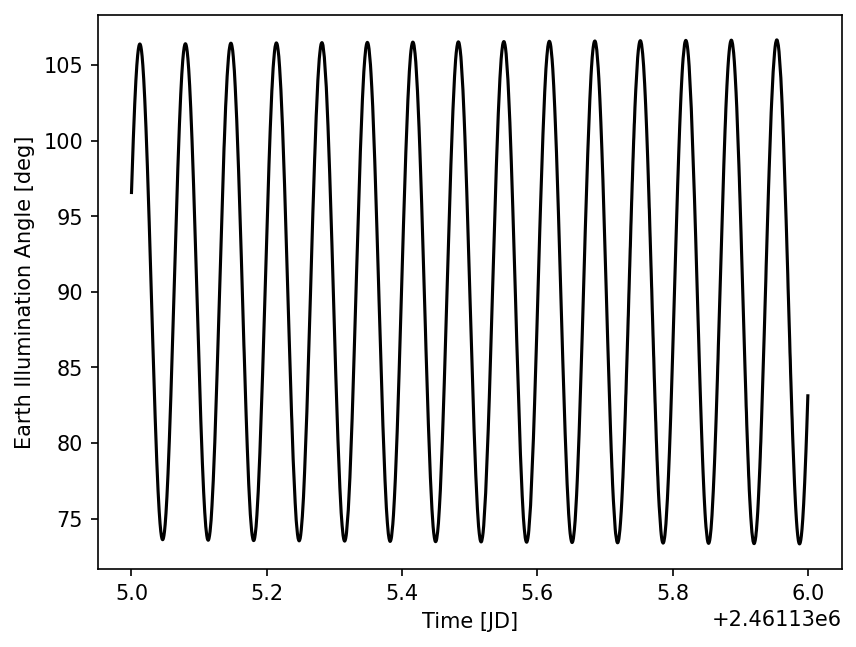

In [5]:
fig, ax = plt.subplots(facecolor='white', dpi=150)
ax.plot(t.jd, illum, c='k')
ax.set(xlabel='Time [JD]', ylabel='Earth Illumination Angle [deg]')

You can see that Pandora passes over the night and day side over the course of one orbit. This pattern changes slowly over the course of a year.

You can also get the angle between the pointing vector and any body

In [6]:
angle = ps.get_angle_to_body(t, direction="boresight", body="earth")

When we plot these against each other we can see how close Pandora is pointing towards the earth during the day and night.

Text(150, 89, 'Day')

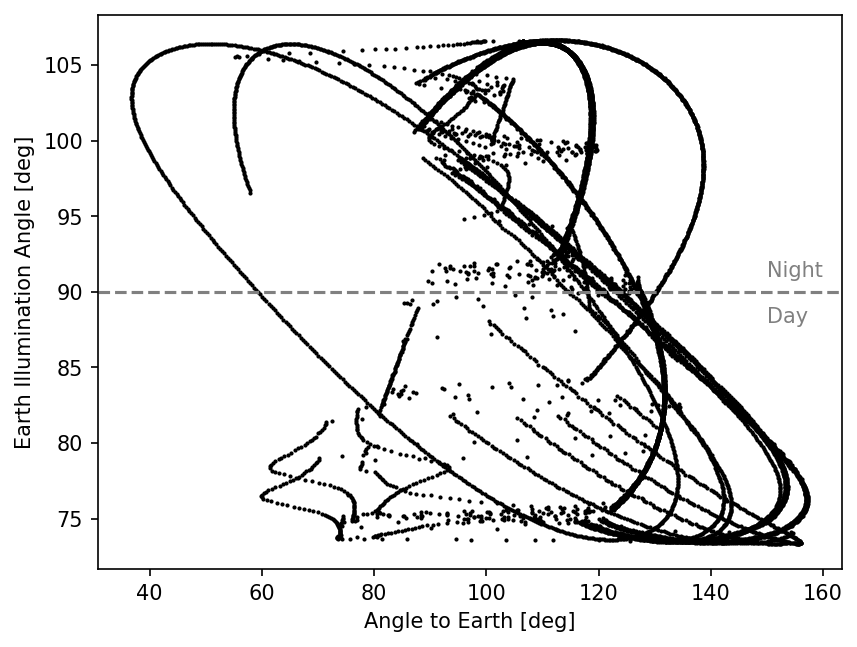

In [7]:
fig, ax = plt.subplots(facecolor='white', dpi=150)
ax.scatter(angle, illum, c='k', s=1)
ax.set(xlabel='Angle to Earth [deg]', ylabel='Earth Illumination Angle [deg]')
ax.axhline(90, ls='--', color='grey')
ax.text(150, 91, 'Night', color='grey')
ax.text(150, 89, 'Day', color='grey', va='top')

We can also get the positiong that Pandora is looking at

In [8]:
ra, dec = ps.get_pointing_radec(t, direction='boresight')

This is the direction in RA and Declination.

[Text(0.5, 0, 'Right Ascension [deg]'), Text(0, 0.5, 'Declination [deg]')]

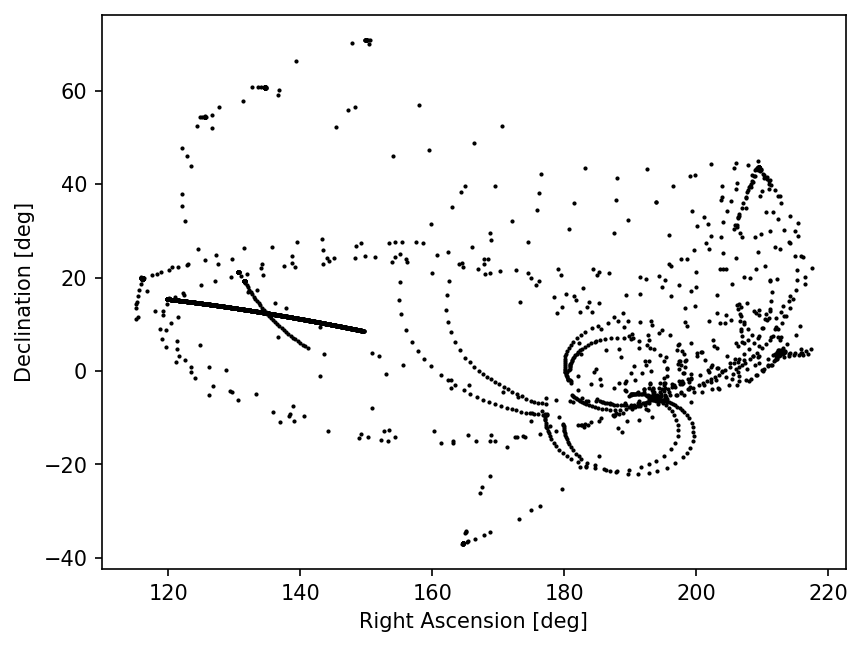

In [9]:
fig, ax = plt.subplots(facecolor='white', dpi=150)
ax.scatter(ra, dec, c='k', s=1)
ax.set(xlabel='Right Ascension [deg]', ylabel='Declination [deg]')